In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv('cs-training.csv')

In [4]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [6]:
#ver quais tipos de dados, achar valores nulos/não nulos#
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [11]:
#colunao duplicada ao exportar csv do kaggle, sem uso para a predição ou análise
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

In [12]:
#identificando duplicatas
n_duplicatas = df.duplicated().sum()
print(f"  Duplicatas encontradas: {n_duplicatas}")

  Duplicatas encontradas: 609


In [13]:
if n_duplicatas > 0:
    df.drop_duplicates(inplace=True)

In [16]:
#identificação de valores ausentes
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({'Ausentes': missing, 'Percentual (%)': missing_pct})
missing_df = missing_df[missing_df['Ausentes'] > 0]

print("\nVariáveis com valores ausentes:")
print(missing_df.to_string())


Variáveis com valores ausentes:
                    Ausentes  Percentual (%)
MonthlyIncome          29221           19.56
NumberOfDependents      3828            2.56


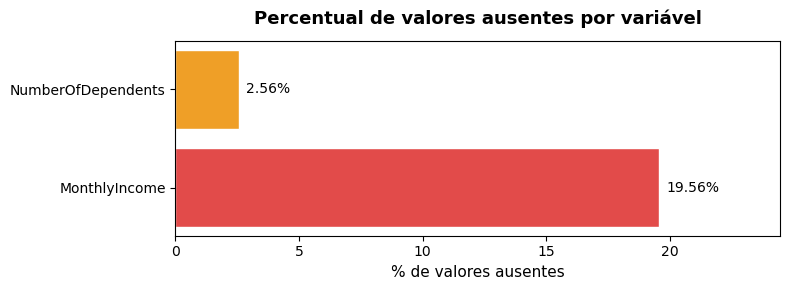

In [22]:
#grafico dos valores ausentes para melhor visualização
fig, ax = plt.subplots(figsize=(8, 3))
cores = ['#E24B4A' if p > 10 else '#EF9F27' for p in missing_df['Percentual (%)']]
bars = ax.barh(missing_df.index, missing_df['Percentual (%)'], color=cores, edgecolor='white')
ax.set_xlabel('% de valores ausentes', fontsize=11)
ax.set_title('Percentual de valores ausentes por variável', fontsize=13, fontweight='bold', pad=12)
for bar, val in zip(bars, missing_df['Percentual (%)']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=10)
ax.set_xlim(0, missing_df['Percentual (%)'].max() * 1.25)
plt.tight_layout()
plt.savefig('grafico_missing_values.png', bbox_inches='tight')
plt.show()
plt.close()

In [37]:
#substituição dos valores ausentes em monthly income pela mediana
mediana_renda = df['MonthlyIncome'].median()
print(f"    Mediana calculada: R$ {mediana_renda:,.2f}")
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(mediana_renda)

    Mediana calculada: R$ 5,400.00


In [39]:
moda_dep = df['NumberOfDependents'].mode()[0]
print(f"    Moda calculada: {moda_dep}")
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(moda_dep)

    Moda calculada: 0


In [42]:
#Tratamento de outliers, remoção de idades menores de 18 e maiores de 100
n_idade_zero = (df['age'] < 18).sum()
n_idade_alta = (df['age'] > 100).sum()
print(f"    Registros com age < 18: {n_idade_zero}")
print(f"    Registros com age > 100: {n_idade_alta}")
print(f"    Min: {df['age'].min()}, Max: {df['age'].max()}")
antes = len(df)
df = df[(df['age'] >= 18) & (df['age'] <= 100)]

    Registros com age < 18: 0
    Registros com age > 100: 0
    Min: 21, Max: 99


In [43]:
print("\n  4b. Variáveis de atraso de pagamento:")
cols_atraso = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]
for col in cols_atraso:
    n_especial = (df[col] >= 90).sum()
    print(f"    '{col}': {n_especial} registros com valor ≥ 90")

antes = len(df)
for col in cols_atraso:
    df = df[df[col] < 90]
removidos = antes - len(df)


  4b. Variáveis de atraso de pagamento:
    'NumberOfTime30-59DaysPastDueNotWorse': 225 registros com valor ≥ 90
    'NumberOfTime60-89DaysPastDueNotWorse': 225 registros com valor ≥ 90
    'NumberOfTimes90DaysLate': 225 registros com valor ≥ 90


In [45]:
print("\n  4c. Variável 'MonthlyIncome' (renda mensal):")
p1  = df['MonthlyIncome'].quantile(0.01)
p99 = df['MonthlyIncome'].quantile(0.99)
n_outliers = ((df['MonthlyIncome'] < p1) | (df['MonthlyIncome'] > p99)).sum()
print(f"    P1 = {p1:,.0f} | P99 = {p99:,.0f}")
print(f"    Registros fora do intervalo [P1, P99]: {n_outliers}")
df['MonthlyIncome'] = df['MonthlyIncome'].clip(lower=p1, upper=p99)


  4c. Variável 'MonthlyIncome' (renda mensal):
    P1 = 0 | P99 = 23,095
    Registros fora do intervalo [P1, P99]: 1492


In [48]:
#removendo taxas de acima de 150%
print("\n  4d. Variável 'RevolvingUtilizationOfUnsecuredLines':")
n_acima_1 = (df['RevolvingUtilizationOfUnsecuredLines'] > 1.5).sum()
print(f"    Registros com utilização > 150%: {n_acima_1}")
df = df[df['RevolvingUtilizationOfUnsecuredLines'] <= 1.5]


  4d. Variável 'RevolvingUtilizationOfUnsecuredLines':
    Registros com utilização > 150%: 0


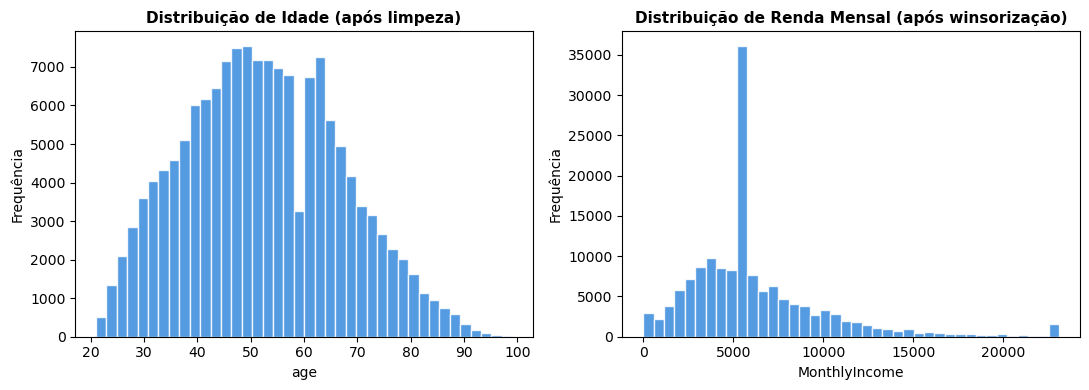


  → Gráfico salvo: grafico_distribuicoes_pos_limpeza.png


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
cols_viz = ['age', 'MonthlyIncome']
titles = ['Distribuição de Idade (após limpeza)', 'Distribuição de Renda Mensal (após winsorização)']
for ax, col, title in zip(axes, cols_viz, titles):
    ax.hist(df[col], bins=40, color='#378ADD', edgecolor='white', alpha=0.85)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequência')
plt.tight_layout()
plt.savefig('grafico_distribuicoes_pos_limpeza.png', bbox_inches='tight')
plt.show()
plt.close()
print("\n  → Gráfico salvo: grafico_distribuicoes_pos_limpeza.png")

In [52]:
#Engenharia de atributos, prepararar os dados para o Teorema de bayes

In [58]:
#idade
bins_idade  = [17, 30, 45, 60, 101]
labels_idade = ['Jovem (18-30)', 'Adulto (31-45)', 'Maduro (46-60)', 'Sênior (61+)']
df['faixa_etaria'] = pd.cut(df['age'], bins=bins_idade, labels=labels_idade)
print("\n  ✔ 'faixa_etaria' criada a partir de 'age'.")
print("    Distribuição:")
print(df['faixa_etaria'].value_counts().sort_index().to_string())


  ✔ 'faixa_etaria' criada a partir de 'age'.
    Distribuição:
faixa_etaria
Jovem (18-30)     10374
Adulto (31-45)    40170
Maduro (46-60)    53304
Sênior (61+)      44704


In [57]:
#atrasos
df['total_atrasos'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse'] +
    df['NumberOfTime60-89DaysPastDueNotWorse'] +
    df['NumberOfTimes90DaysLate']
)
print("\n  ✔ 'total_atrasos' criada (soma das 3 colunas de atraso).")
print(f"    Min: {df['total_atrasos'].min()} | Max: {df['total_atrasos'].max()} | Média: {df['total_atrasos'].mean():.2f}")


  ✔ 'total_atrasos' criada (soma das 3 colunas de atraso).
    Min: 0 | Max: 19 | Média: 0.40


In [55]:
#renda
bins_renda  = [-1, 2000, 5000, 10000, 99999999]
labels_renda = ['Baixa (<2k)', 'Média (2k-5k)', 'Alta (5k-10k)', 'Muito Alta (>10k)']
df['faixa_renda'] = pd.cut(df['MonthlyIncome'], bins=bins_renda, labels=labels_renda)
print("\n  ✔ 'faixa_renda' criada a partir de 'MonthlyIncome'.")
print("    Distribuição:")
print(df['faixa_renda'].value_counts().sort_index().to_string())


  ✔ 'faixa_renda' criada a partir de 'MonthlyIncome'.
    Distribuição:
faixa_renda
Baixa (<2k)          11788
Média (2k-5k)        43608
Alta (5k-10k)        74912
Muito Alta (>10k)    18244


In [60]:
#atrasos
def perfil_atraso(x):
    if x == 0:
        return 'Sem atrasos'
    elif x <= 2:
        return 'Poucos atrasos'
    else:
        return 'Muitos atrasos'

df['perfil_historico'] = df['total_atrasos'].apply(perfil_atraso)
print("\n  ✔ 'perfil_historico' criada a partir de 'total_atrasos'.")
print("    Distribuição:")
print(df['perfil_historico'].value_counts().to_string())


  ✔ 'perfil_historico' criada a partir de 'total_atrasos'.
    Distribuição:
perfil_historico
Sem atrasos       118766
Poucos atrasos     23038
Muitos atrasos      6748


In [62]:
print("\n" + "=" * 65)
print(" RELATÓRIO FINAL — RESUMO DO TRATAMENTO")
print("=" * 65)

print(f"\n  Dimensões originais:  150.000 × 12")
print(f"  Dimensões finais:     {df.shape[0]:,} × {df.shape[1]}")
print(f"  Registros removidos:  {150000 - df.shape[0]:,}")
print(f"  Colunas removidas:    1 (índice duplicado)")
print(f"  Novas colunas criadas: 4 (faixa_etaria, total_atrasos, faixa_renda, perfil_historico)")
print(f"  Valores ausentes restantes: {df.isnull().sum().sum()}")

print("\n  Variável alvo (SeriousDlqin2yrs):")
contagem = df['SeriousDlqin2yrs'].value_counts()
pct = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100
print(f"    Classe 0 (adimplente):    {contagem[0]:,} ({pct[0]:.1f}%)")
print(f"    Classe 1 (inadimplente):  {contagem[1]:,} ({pct[1]:.1f}%)")
print(f"    → Dataset desbalanceado: atenção ao avaliar os classificadores!")

# --- Gráfico: variável alvo ---
fig, ax = plt.subplots(figsize=(6, 4))
cores_alvo = ['#378ADD', '#E24B4A']
rotulos = ['Adimplente (0)', 'Inadimplente (1)']
bars = ax.bar(rotulos, [contagem[0], contagem[1]], color=cores_alvo, edgecolor='white', width=0.5)
ax.set_title('Distribuição da Variável Alvo\n(SeriousDlqin2yrs)', fontsize=13, fontweight='bold')
ax.set_ylabel('Quantidade de registros')
for bar, val, p in zip(bars, [contagem[0], contagem[1]], [pct[0], pct[1]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}\n({p:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(0, max(contagem[0], contagem[1]) * 1.2)
plt.tight_layout()
plt.savefig('grafico_variavel_alvo.png', bbox_inches='tight')
plt.close()
print("\n  → Gráfico salvo: grafico_variavel_alvo.png")



 RELATÓRIO FINAL — RESUMO DO TRATAMENTO

  Dimensões originais:  150.000 × 12
  Dimensões finais:     148,552 × 15
  Registros removidos:  1,448
  Colunas removidas:    1 (índice duplicado)
  Novas colunas criadas: 4 (faixa_etaria, total_atrasos, faixa_renda, perfil_historico)
  Valores ausentes restantes: 0

  Variável alvo (SeriousDlqin2yrs):
    Classe 0 (adimplente):    138,836 (93.5%)
    Classe 1 (inadimplente):  9,716 (6.5%)
    → Dataset desbalanceado: atenção ao avaliar os classificadores!

  → Gráfico salvo: grafico_variavel_alvo.png


In [64]:
df.to_csv('dataset_limpo.csv', index=False)